In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Data Preparation

In [2]:
df = pd.read_csv("HouseSale.csv")
df

,_________,____________,____________.1,________ (__),zone Rating,_______ (USD)
0,50.3,5,2,8,1,206042
1,50.9,2,1,21,1,179398
2,53.4,3,1,10,1,187509
3,56.4,5,3,8,1,242866
4,56.6,1,3,16,1,158455
...,...,...,...,...,...,...
356,497.4,5,2,26,5,1107045
357,499.5,3,2,19,5,1092027
358,499.6,1,3,12,5,1102534
359,499.6,5,1,23,5,1070454


In [3]:
df.shape

(361, 6)

In [4]:
df.isna().sum()

_________         0
____________      0
____________.1    0
________ (__)     0
zone Rating       0
_______ (USD)     0
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 361 entries, 0 to 360
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   _________       361 non-null    object
 1   ____________    361 non-null    object
 2   ____________.1  361 non-null    object
 3   ________ (__)   361 non-null    object
 4   zone Rating     361 non-null    object
 5   _______ (USD)   361 non-null    object
dtypes: object(6)
memory usage: 17.1+ KB


In [6]:
df = df.apply(pd.to_numeric, errors='coerce')

In [7]:
df.columns = [
    'sq_meters',   # ตารางเมตร
    'bedrooms',    # จำนวนห้องนอน
    'bathrooms',   # จำนวนห้องน้ำ
    'house_age',   # อายุบ้าน (ปี)
    'zone_rating', # zone Rating
    'price_usd'    # ราคาขาย (USD)
]

print(df.head())

   sq_meters  bedrooms  bathrooms  house_age  zone_rating  price_usd
0       50.3       5.0        2.0        8.0          1.0   206042.0
1       50.9       2.0        1.0       21.0          1.0   179398.0
2       53.4       3.0        1.0       10.0          1.0   187509.0
3       56.4       5.0        3.0        8.0          1.0   242866.0
4       56.6       1.0        3.0       16.0          1.0   158455.0


In [8]:
avg_max = df.agg(['mean', 'max'])
print(avg_max)

       sq_meters  bedrooms  bathrooms  house_age  zone_rating    price_usd
mean  277.084444  2.961111   1.969444  16.647222     3.627778   631059.675
max   499.600000  5.000000   3.000000  29.000000     5.000000  1108237.000


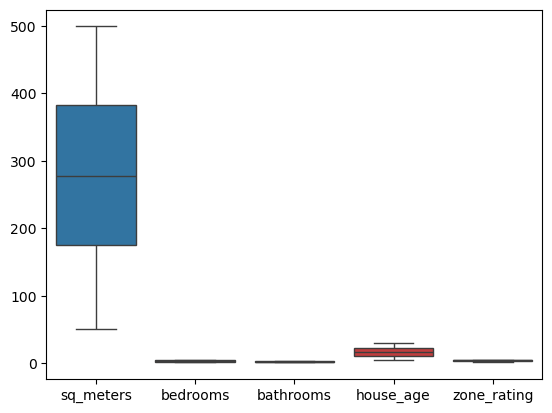

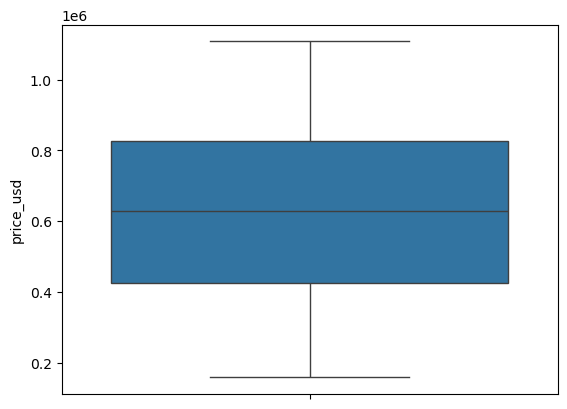

In [9]:
sns.boxplot(data=df.iloc[:, 0:5])
plt.show()

sns.boxplot(data=df.iloc[:, -1])
plt.show()

<Axes: >

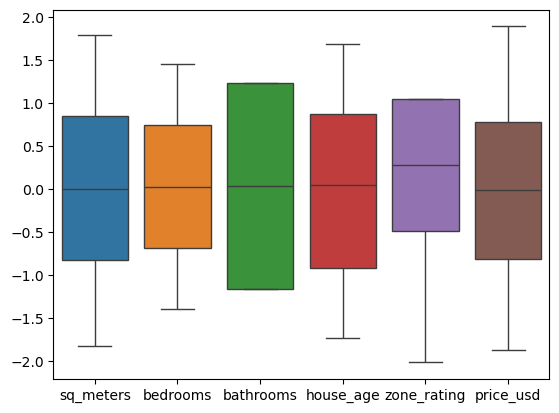

In [10]:
df_numeric = df.select_dtypes(include=['number']).drop(columns=['_______(USD)'], errors='ignore')

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_numeric)
df_scaled = pd.DataFrame(scaled_data, columns=df_numeric.columns)

sns.boxplot(data=df_scaled)

In [11]:
df_scaled = df_scaled.fillna(df_scaled.mean())

In [12]:
X = df_scaled.iloc[:, :-1]
y = df_scaled.iloc[:, -1]

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=67)